# Exercise 1 - Two level system

The purpose of this exercise is to introduce you to python and jupyter notebooks and to demonstrate how you can use python to simulate a simple quantum system.
No programming knowlegde is required to run this example.

## Physical background

In this exercise we simulate the interaction of a two-level-system with a laser pulse.

The Hamiltonian of the two-level-system is defined as
$$
H = H_0 + H_1(t)
\;,
$$
where $H_0$ is the time-independent Hamiltonion of the system and $H_1(t)=E(t) \, V$ describes the interaction with the field $E(t)$.

Choosing the eigenstates of $H_0$ as a basis, $\{|0\rangle, |1\rangle\}$, we can represent the system Hamiltonian by
$$
H_0 = -\frac{\omega}{2}
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
$$
and the interaction matrix $V$ by
$$
V = -\mu_{01}
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
\;.
$$
Here, $\omega>0$ is the energy splitting between the two levels and $\mu_{01}$ is the transition matrix element.

## Selected Python packages

The number one python packages for numerics and data analysis are [NumPy](https://numpy.org/doc/stable/user/whatisnumpy.html) and [SciPy](https://docs.scipy.org/doc/scipy/reference/). NumPy provides you with the basic data structures (i.e. multidimensional arrays), functions for array manipulation (reshaping, summation etc.), elementary mathematical functions (`sqrt`, `exp`, `cos` etc.) and basic linear algebra (diagonalisation etc.).
SciPy adds more specialised functionality like signal processing, regression, numerical integration, differential equation solvers and much more.

The python package [Matplotlib](https://matplotlib.org/) is the base package for 2d data visualisation. It closely resembles the plotting syntax from Matlab.

[QuTiP](https://qutip.org/) is a great package for simulating quantum mechanical systems. It is developed for simulating closed and open quantum systems with a focus on quantum information processing. In particular, it defines a data structure for quantum objects (`qutip.Qobj`) and comes with a solver for the Schrödinger and Master equation (`qutip.mesolve()`).

## How to use this notebook

*You can evaluate all cells marked with `[n]:` by* **selecting it and hitting SHIFT+ENTER** *or the play button in the top panel.*

Just go through the notebook and evaluate the cells one after another. You can also change the cell to play around with the values and reevaluate it. If you do so, make sure to evaluate all the cells that rely on the one you changed. Have fun!

## Let's start!

First we need to load the python packages that we are going to use in the following:

In [1]:
import matplotlib.pyplot as plt  # for plotting
import numpy as np               # for numerics
import qutip                     # for quantum mechanics

# Some functions for easy access:
from numpy import pi, sqrt, exp, sin, cos

We start with defining the time interval for the propagation. For numerical calculations, we need to represent the time interval by a grid with a finite amount of grid points.

Let the time grid start at `t_start=0` and end at `t_stop=50` with a total amount of `Nt=10000` grid points. We can create such a grid with NumPy's `np.linspace()` function:

In [2]:
t_start = 0
t_stop = 50
Nt = 10000
t = np.linspace(t_start, t_stop, Nt)

## The model

Now we need to define the individual parts of the Hamiltonian. For the simulation use the following parameters:

In [3]:
omega = 10
mu_01 = 1

We need the matrix for the time independent Hamiltonian $H_0$ ...

In [4]:
H0 = -omega/2 * qutip.Qobj(
    np.array([[1,  0],
              [0, -1]])
)

display(H0) # shows the result

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[-5.  0.]
 [ 0.  5.]]

... and the interaction matrix $V$:

In [5]:
V = -mu_01 * qutip.Qobj(
    np.array([[0, 1],
              [1, 0]])
)

display(V) # shows the result

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[ 0. -1.]
 [-1.  0.]]

Next, we need to define the electric field `E` on the time grid `t`.

We assume a Gaussian shaped pulse,
$$
E(t) = E_0 \, e^{-(t-t_0)^2 / (2 \tau^2)} \, \cos(w_l (t-t_0) + \phi)
$$
with the following parameters: $\omega_l=\omega$, $\phi=0$, $E_0=0.2$ and $t_0=25$. 

Choose a value for the pulse duration $\tau$. The duration should not be larger than $7.5$, in order to fit completly into our time grid.

In [6]:
t_0 = 25
w_l = omega
E0 = 0.2
phi = 0
tau = 2.5

E = E0 * cos(w_l*(t-t_0) + phi) * exp(-(t-t_0)**2/(2*tau**2))

Now we collect everything together and assemble the total Hamiltonian of our system. The QuTiP package wants us to store the Hamiltonian as nested list in the following form:

In [7]:
H = [H0, [V, E]]

As a last step in setting up the model, we define the two states.

In [8]:
psi0 = qutip.Qobj(np.array([1, 0])) # State |0>
psi1 = qutip.Qobj(np.array([0, 1])) # State |1>

display(psi0, psi1) # shows the result

Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
Qobj data =
[[1.]
 [0.]]

Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
Qobj data =
[[0.]
 [1.]]

## Propagation and results

Before we can start with the propagation, we first need to define the observables that we are interested in. For the present case, we are interested in the population dynamics. To track the population of the two levels, we define the projectors $\hat{P}_{i} =
|i\rangle\langle i|$.

In [9]:
proj0 = psi0 * psi0.dag()
proj1 = psi1 * psi1.dag()

Having them set up, we can use QuTiP's **m**aster **e**quation **solve**r function to obtain the dynamics over time.
As initial state of our simulation we choose the ground state, $|0\rangle$.

In [10]:
output = qutip.mesolve(H, psi0, t, e_ops=[proj0, proj1])

Now let's plot the population dynamics:

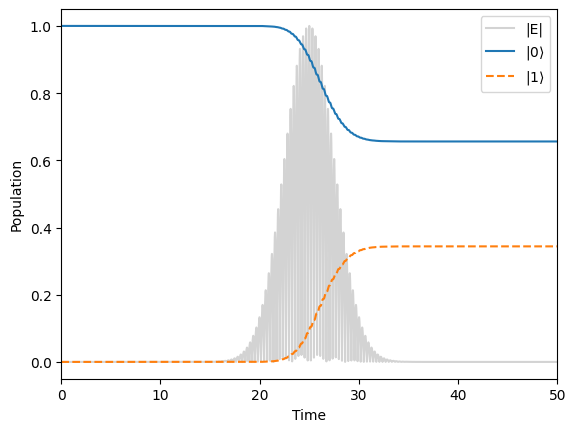

In [11]:
fig, ax = plt.subplots()
ax.plot(t, np.abs(E)/np.abs(E).max(), '-', color='lightgrey', label='|E|')
ax.plot(t, output.expect[0], '-', label=r'$|0\rangle$')
ax.plot(t, output.expect[1], '--', label=r'$|1\rangle$')
ax.set_xlim(t.min(), t.max())
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()
plt.show()

Play with the pulse parameters and observe how this affects the population dynamics. Can you find a combination of parameters that produce a complete population inversion? What do you need to obtain a full Rabi cycle? What happens if you change the frequency of the laser pulse?